## Parallel AMS

In [1]:
from utils import hash_func
import numpy as np

def parallel_ams(timestep, r=5):
    '''
    Description:
        Runs AMS algorithm in parallel
    Parameters:
        timestep: timestep to start ams estimation
        r: number of algorithm repetitions
    Outputs:
        returns estimated 2 norm
    '''
    #hist: global var shared among threads
    #stream: global var shared among threads
    #m: global var shared among threads
    
    hist[timestep] = np.zeros(r)
    for i in range(timestep, m):
        # generate r random signs
        for j in range(r):
            v_i = 2*hash_func(j, stream[i], 2) - 1
            hist[timestep][j] += v_i

In [5]:
import matplotlib.pyplot as plt

def plot_result(hist):
    '''
    Description:
        Helper function to plot results of parallelized AMS/AMSA
    Inputs:
        hist: histogram of norm estimates
    '''
    
    indices = []
    est = []
    
    for time, norms in hist.items():
        indices.append(time)
        est.append(np.sqrt(np.median(norms**2)))
    _, ax = plt.subplots()
    
    ax.scatter(indices, est)
    ax.set_xlabel("Starting Timestep")
    ax.set_ylabel("Estimated 2 Norm")
    ax.set_title(f"Estimated 2 Norm per Timestep")
    
    plt.show()

### Uniform Stream Test

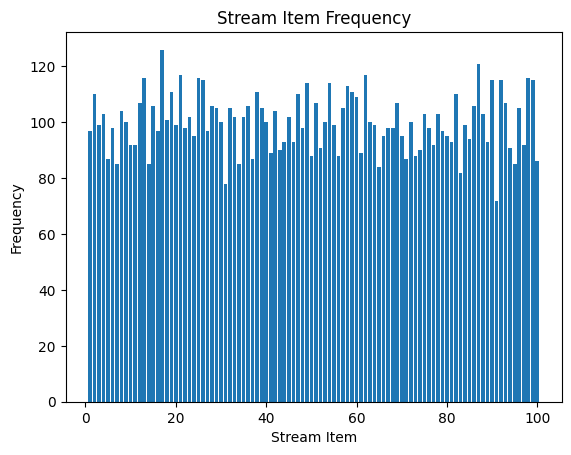

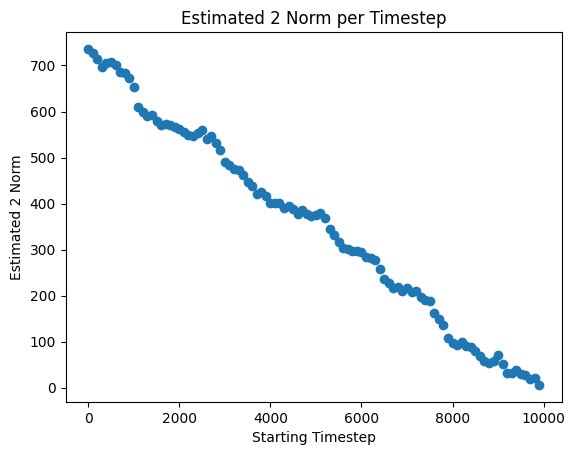

In [7]:
from utils import generate_stream_uniform, plot_stream

n_uniform = 100
m_uniform = 10000
num_threads = 100

stream_uniform, freq_uniform = generate_stream_uniform(n_uniform, m_uniform)
plot_stream(stream_uniform)

# init shared variables
hist = {}
m=m_uniform
stream=stream_uniform

# process the stream and spawn threads
for time in range(m):
    if time % num_threads == 0:
        parallel_ams(time)

# visualize the results
plot_result(hist)

### Skewed Stream Test

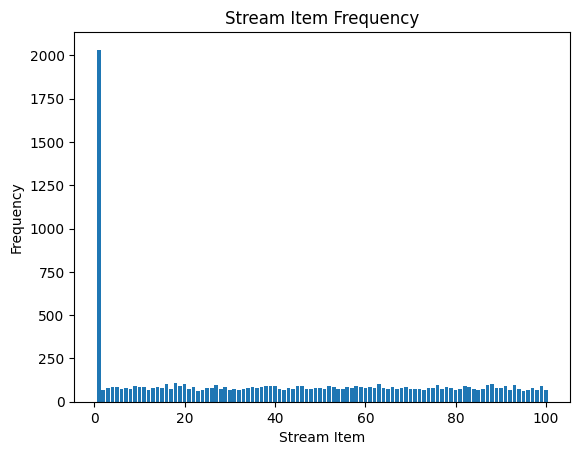

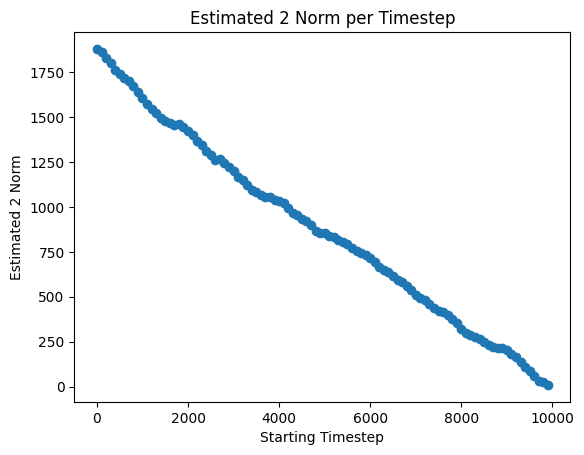

In [9]:
from utils import generate_stream_skewed, plot_stream
n_skewed = 100
m_skewed = 10000
num_threads = 100

stream_skewed, freq_skewed = generate_stream_skewed(n=n_skewed,m=m_skewed, q=1, k=2)
plot_stream(stream_skewed)

# init shared variables
hist = {}
m=m_skewed
stream=stream_skewed

# process the stream and spawn threads
for time in range(m):
    if time % num_threads == 0:
        parallel_ams(time)

#visualize the result
plot_result(hist)

## Implement Thread Pruning

In [10]:
def prune_threads():
    # i is index, t_i is thread identity
    i = 0
    while (i < len(threads_vec)):
        # check boundary
        if (i >= len(threads_vec) - 2):
            i += 1
            continue
        t_i = threads_vec[i]
        ams_t = np.sqrt(np.median(hist[t_i]**2))
        # check adjacent thread
        t_i2 = threads_vec[i+2]
        ams_t2 = np.sqrt(np.median(hist[t_i2]**2))
        # check distance, prune hist, threads
        if (max(ams_t, ams_t2)/min(ams_t, ams_t2) <= 2):
            # remove the thread in between
            t_i1 = threads_vec[i+1]
            threads_vec.pop(i+1)
            hist.pop(t_i1)
            i -= 1
        i += 1

### Uniform Stream Test

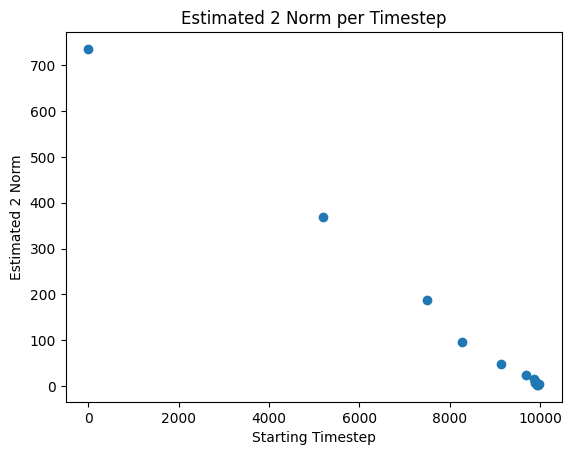

In [11]:
# set up shared variables
num_threads_max = 20 # treat as hyperparam
threads_vec = [] # stores thread identity (timestep)

stream = stream_uniform
m = m_uniform
hist = {} # thread id : list of ams values

plot_stream(stream_uniform)

for time in range(0, m, num_threads_max):
    # check if threads is full
    if (len(threads_vec) == num_threads_max):
        prune_threads()
    # if there is space, spawn a new thread
    if (len(threads_vec) < num_threads_max):
        parallel_ams(time)
        threads_vec.append(time)

plot_result(hist)

### Skewed Stream Test

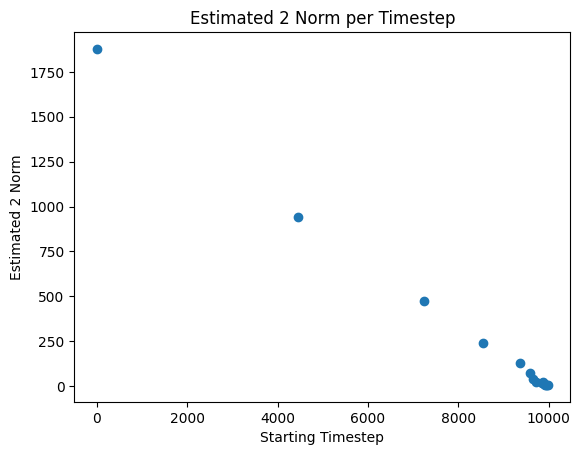

In [13]:
# set up shared variables
num_threads_max = 20 # treat as hyperparam
threads_vec = [] # stores thread identity (timestep)

stream = stream_skewed
m = m_skewed
hist = {} # thread id : list of ams values

plot_stream(stream_skewed)

# try skewed
for time in range(0, m, num_threads_max):
    # check if threads is full
    if (len(threads_vec) == num_threads_max):
        prune_threads()
    # if there is space, spawn a new thread
    if (len(threads_vec) < num_threads_max):
        parallel_ams(time)
        threads_vec.append(time)

plot_result(hist)